# 3D cartonization solver: decision brief

> **Recommendation:** use **Best** when packing quality justifies a bounded sub-second search; use **Fast** where tail latency is the priority. Best preserves Fast's validated plan and does not lose to any policy-compliant iHub reference result in this benchmark.

The evidence is organized around five decisions—not around implementation details:

1. **Trust:** are every placement and configurable rule independently validated?
2. **Quality:** does exact Best repair the known greedy packing gaps?
3. **Fair comparison:** what happens after invalid iHub fill-cap results are separated?
4. **Operational fit:** is the quality gain still fast enough, and are timeouts explicit?
5. **Evaluation integrity:** can changing the stored iHub answer influence the recommendation?

Each section starts with the insight. Source rows, full solver logs, and placement-level evidence are still available, but secondary detail is collapsed so the main argument remains scannable. The final 2,000-order benchmark is recomputed from the masked dataset rather than copied into the notebook.

## Units

- Item and carton dimensions: **millimetres (mm)**
- Buffer and packed XYZ coordinates: **millimetres (mm)**
- Derived volumes: **cubic millimetres (mm³)**
- Item and carton weight: **kilograms (kg)**

These units match the source dataset and the solver contract, so no conversion is required. All order identifiers and item codes in this development dataset are masked.

In [1]:
import copy
import json
import math
import statistics
from contextlib import redirect_stdout
from html import escape as html_escape
from io import StringIO
from pathlib import Path
import sys

from IPython.display import HTML, Markdown, display

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

from bin_packing_3d import (
    display_table, make_table, result_tables, solve_order, visualize_result,
)

def show_details(summary, content):
    body = content._repr_html_() if hasattr(content, '_repr_html_') else f'<pre>{html_escape(str(content))}</pre>'
    display(HTML(f'<details><summary><strong>{html_escape(summary)}</strong></summary>{body}</details>'))

## 1. The contract is configurable—not hidden

The user supplies the carton catalogue and operational constraints directly to `solve_order()`. Nothing in Best silently changes the 70% high-item-count fill cap, the 6 mm clearance, weight limits, or rotation rules. The detailed catalogue is reference material, so it is collapsed by default.

In [2]:
DATA_PATH = ROOT / 'data' / 'raw' / 'data_samples_v2.json'
with DATA_PATH.open(encoding='utf-8') as file:
    ihub_records = {record['input']['OrderId']: record for record in json.load(file)}

catalogue_source = next(iter(ihub_records.values()))['input']
boxes = [dict(box) for box in catalogue_source['Bins']['BinsList']]
box_rows = [
    {
        'Code': box['Code'], 'Length (mm)': box['Length'],
        'Width (mm)': box['Width'], 'Height (mm)': box['Height'],
        'Max weight (kg)': box['MaxWeight'],
    }
    for box in boxes
]
show_details('Show the six candidate cartons', make_table(box_rows))

Code,Length (mm),Width (mm),Height (mm),Max weight (kg)
Box2,270.0,170.0,115.0,20
Box4,340.0,260.0,150.0,20
Box5,340.0,260.0,235.0,20
Box6,340.0,260.0,280.0,20
Box8,290.0,180.0,280.0,20
Box9,440.0,345.0,280.0,20


### Rules visible at the call boundary

The values below come from the same iHub request. The important reading is: **up to six physical items may use 100% of usable volume; seven or more are capped at 70%; and every carton loses 6 mm of usable height.** Logging and visualization are explicit options and do not change the solution.

In [3]:
source_parameters = catalogue_source['Bins']['Parameters']
source_buffer = source_parameters['BinBuffer']
high_item_count_threshold = source_parameters['BinMaxFillCheckMinItemQty']
high_item_count_max_fill_pct = source_parameters['BinMaxFillPct']
max_fill_pct = 100
bin_buffer = {
    'length': source_buffer['Length'],
    'width': source_buffer['Width'],
    'height': source_buffer['Height'],
}
display_table([
    {'Rule': 'Default mode', 'Configured value': 'fast'},
    {'Rule': 'Full-fill item threshold', 'Configured value': high_item_count_threshold},
    {'Rule': 'Maximum fill above threshold', 'Configured value': f'{high_item_count_max_fill_pct}%'},
    {'Rule': 'Maximum fill at/below threshold', 'Configured value': f'{max_fill_pct}%'},
    {'Rule': 'Carton clearance (L × W × H)', 'Configured value': f"{bin_buffer['length']} × {bin_buffer['width']} × {bin_buffer['height']} mm"},
])

Rule,Configured value
Default mode,fast
Full-fill item threshold,6
Maximum fill above threshold,70%
Maximum fill at/below threshold,100%
Carton clearance (L × W × H),0 × 0 × 6 mm


## 2. What the solver calculates under the hood

The solver does not predict an iHub carton. It builds a packing from the supplied items, cartons, and rules. The calculation proceeds in this order:

| Stage | Calculation | Decision produced |
| --- | --- | --- |
| Expand demand | One physical instance per `Quantity` unit | Stable IDs such as `SKU#1`, `SKU#2` |
| Apply clearance | `usable axis = external axis - configured buffer` | The 6 mm height buffer reduces every candidate carton |
| Select fill policy | Use `max_fill_pct` at/below the item threshold; above it use the smaller of the normal and high-count caps | Orders with more than six items are capped at 70% here |
| Screen cartons | Check individual orientation, aggregate weight, and `item volume ≤ usable volume × fill cap` | Impossible candidates are rejected cheaply; passing is not yet proof |
| Fast construction | Order larger items first, score feasible XYZ placements, and try promising fixed-carton combinations | A complete validated fallback plan |
| Best feasibility | For each carton combination, solve orientation, carton assignment, XYZ boundary, pairwise non-overlap, weight, and fill constraints together | Exact yes/no feasibility for that combination |
| Optimize | Test combinations by `(carton count, largest external carton volume, total external carton volume)` | The first feasible combination is the preferred objective |
| Validate independently | Recheck accounting, orientation, boundaries, collision, weight, fill, and carton identity without trusting the solver | Only a validated plan can be returned |

Best can claim `optimality_proven=True` only when every better carton combination was proven infeasible. If the time budget expires, it returns Fast's already validated plan with `search_status='time_limit'`. This is exact feasibility inside a bounded search—not a learned model and not a lookup of the reference answer.

## 3. One order, end to end: why Box4 wins

**Insight:** screening narrows the search, but only 3D placement proves the answer. For this eight-item order, five cartons pass the volume screen. Fast then constructs and independently validates a complete one-Box4 arrangement—the smallest successful carton. The visualization is the result; placement rows and the full decision trace are available on demand.

In [4]:
source_order_80 = ihub_records[80]['input']
items_order_80 = [dict(item) for item in source_order_80['Items']['ItemsList']]
order_80 = {
    'OrderId': source_order_80['OrderId'],
    'OrderNo': source_order_80['OrderNo'],
    'Items': items_order_80,
}
item_rows_80 = [
    {
        **item, 'Length (mm)': item['Length'], 'Width (mm)': item['Width'],
        'Height (mm)': item['Height'], 'Weight (kg)': item['Weight'],
    }
    for item in items_order_80
]
show_details('Show order 80 source items', make_table(item_rows_80, [
    'Code', 'Length (mm)', 'Width (mm)', 'Height (mm)', 'Weight (kg)',
    'Quantity', 'VerticalRotation', 'UOM',
]))

Code,Length (mm),Width (mm),Height (mm),Weight (kg),Quantity,VerticalRotation,UOM
30,245,40,125.0,0.2,1,1,BOX
9,255,40,192.0,1.25,1,1,SET
95,70,70,60.0,0.1458,1,1,EA
103,55,50,175.0,0.2125,2,1,EA
2,110,65,110.0,0.2292,1,1,BOX
332,60,60,120.0,0.2083,1,1,EA
73,50,50,90.0,0.0722,1,1,EA


### Decision: one Box4, validated

Status,Strategy,Total cartons,Carton number,Carton,Box type,Item qty,Usable fill (%),Runtime (ms),Valid
success,fast_fit,1,1,carton-1,Box4,8,46.22,1.451,True


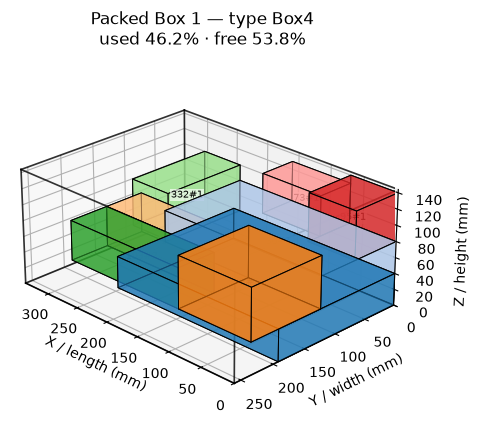

Carton,Box type,Item,Packed L (mm),Packed W (mm),Packed H (mm),X (mm),Y (mm),Z (mm),Volume (mm^3)
carton-1,Box4,9#1,255.0,192.0,40.0,0.0,0.0,0.0,1958400.0
carton-1,Box4,30#1,245.0,125.0,40.0,0.0,0.0,40.0,1225000.0
carton-1,Box4,2#1,110.0,110.0,65.0,0.0,125.0,40.0,786500.0
carton-1,Box4,103#1,175.0,55.0,50.0,110.0,125.0,40.0,481250.0
carton-1,Box4,103#2,175.0,55.0,50.0,110.0,180.0,40.0,481250.0
carton-1,Box4,332#1,60.0,120.0,60.0,245.0,0.0,40.0,432000.0
carton-1,Box4,95#1,70.0,70.0,60.0,0.0,0.0,80.0,294000.0
carton-1,Box4,73#1,90.0,50.0,50.0,70.0,0.0,80.0,225000.0


In [5]:
order_80_log = StringIO()
with redirect_stdout(order_80_log):
    order_80_result = solve_order(
        order_80,
        boxes,
        mode='fast',
        high_item_count_threshold=high_item_count_threshold,
        high_item_count_max_fill_pct=high_item_count_max_fill_pct,
        max_fill_pct=max_fill_pct,
        bin_buffer=bin_buffer,
        dimension_unit='mm',
        logs=True,
    )

order_80_summary, order_80_placements = result_tables(order_80_result)
display(Markdown('### Decision: one Box4, validated'))
display(order_80_summary)
visualize_result(order_80_result)
show_details('Show all item placements', order_80_placements)
show_details('Show the full carton-screening and 3D-search trace', order_80_log.getvalue())

## 4. A constraint must change the answer

**Insight:** respecting `VerticalRotation` is observable behavior, not a checkbox. Order 285 contains five upright-only units. Best selects one Box8 while preserving their vertical axis. The counterfactual below shows why a seemingly tighter result obtained by laying them down would be invalid.

In [6]:
source_order_285 = ihub_records[285]['input']
items_order_285 = [dict(item) for item in source_order_285['Items']['ItemsList']]
order_285 = {
    'OrderId': source_order_285['OrderId'],
    'OrderNo': source_order_285['OrderNo'],
    'Items': items_order_285,
}
item_rows_285 = [
    {
        **item, 'Length (mm)': item['Length'], 'Width (mm)': item['Width'],
        'Height (mm)': item['Height'], 'Weight (kg)': item['Weight'],
    }
    for item in items_order_285
]
show_details('Show order 285 source items', make_table(item_rows_285, [
    'Code', 'Length (mm)', 'Width (mm)', 'Height (mm)', 'Weight (kg)',
    'Quantity', 'VerticalRotation', 'UOM',
]))

Code,Length (mm),Width (mm),Height (mm),Weight (kg),Quantity,VerticalRotation,UOM
94,40,40,130.0,0.1143,1,1,EA
136,80,80,210.0,0.65,1,0,EA
95,70,70,60.0,0.1458,1,1,EA
327,100,70,160.0,0.2667,1,1,EA
375,70,70,200.0,0.6667,1,0,EA
188,70,70,142.0,0.4167,2,0,EA
138,80,80,210.0,0.65,1,0,EA


In [7]:
order_285_result = solve_order(
    order_285,
    boxes,
    mode='best',
    high_item_count_threshold=high_item_count_threshold,
    high_item_count_max_fill_pct=high_item_count_max_fill_pct,
    max_fill_pct=max_fill_pct,
    bin_buffer=bin_buffer,
    dimension_unit='mm',
)
order_285_summary, order_285_placements = result_tables(order_285_result)
display(Markdown('### Valid decision: preserve upright orientation'))
display(order_285_summary)
show_details('Show validated item orientations and coordinates', order_285_placements)

### Valid decision: preserve upright orientation

Status,Strategy,Total cartons,Carton number,Carton,Box type,Item qty,Usable fill (%),Runtime (ms),Valid
success,best_fit,1,1,carton-1,Box8,8,46.72,84.707,True


Carton,Box type,Item,Packed L (mm),Packed W (mm),Packed H (mm),X (mm),Y (mm),Z (mm),Volume (mm^3)
carton-1,Box8,94#1,40.0,130.0,40.0,160.001,0.0,144.001,208000.0
carton-1,Box8,136#1,80.0,80.0,210.0,70.0,100.0,0.0,1344000.0
carton-1,Box8,95#1,70.0,70.0,60.0,0.0,0.0,204.001,294000.0
carton-1,Box8,327#1,70.0,100.0,160.0,0.0,0.0,0.0,1120000.0
carton-1,Box8,375#1,70.0,70.0,200.0,0.0,100.0,0.0,980000.0
carton-1,Box8,188#1,70.0,70.0,142.0,70.0,0.0,0.0,695800.0
carton-1,Box8,188#2,70.0,70.0,142.0,140.0,0.0,0.0,695800.0
carton-1,Box8,138#1,80.0,80.0,210.0,210.0,0.0,0.0,1344000.0


### Counterfactual: the smaller-looking answer cheats

If all items are incorrectly made rotatable, the order fits Box4. That result looks more efficient but violates five source constraints. The correct conclusion is not “Box4 is better”; it is **“Box4 is infeasible for the actual order.”**

In [8]:
items_285_ignore_upright = [
    {**item, 'VerticalRotation': 1} for item in items_order_285
]
order_285_ignore_upright = {**order_285, 'Items': items_285_ignore_upright}
order_285_ignore_upright_result = solve_order(
    order_285_ignore_upright,
    boxes,
    mode='best',
    high_item_count_threshold=high_item_count_threshold,
    high_item_count_max_fill_pct=high_item_count_max_fill_pct,
    max_fill_pct=max_fill_pct,
    bin_buffer=bin_buffer,
    dimension_unit='mm',
)

display_table([
    {
        'Scenario': 'Respect source rotation rules',
        'Box type': order_285_result.packed_boxes[0].box_code,
        'Item qty': order_285_result.metrics.packed_item_count,
        'Usable fill (%)': round(order_285_result.metrics.boxes[0].usable_utilization_pct, 2),
        'Valid for source order': 'YES',
    },
    {
        'Scenario': 'Ignore upright-only restrictions',
        'Box type': order_285_ignore_upright_result.packed_boxes[0].box_code,
        'Item qty': order_285_ignore_upright_result.metrics.packed_item_count,
        'Usable fill (%)': round(order_285_ignore_upright_result.metrics.boxes[0].usable_utilization_pct, 2),
        'Valid for source order': 'NO — 5 upright-only units are laid down',
    },
])

source_item_by_code_285 = {item['Code']: item for item in items_order_285}
ignored_rotation_rows = []
for placement in order_285_ignore_upright_result.placements:
    source_item = source_item_by_code_285[placement.item_code]
    if source_item['VerticalRotation'] == 0:
        ignored_rotation_rows.append({
            'Item': placement.item_instance_id,
            'Required source orientation (mm)': f"{source_item['Length']:g} × {source_item['Width']:g} × {source_item['Height']:g}",
            'Counterfactual packed orientation (mm)': f"{placement.orientation.length:g} × {placement.orientation.width:g} × {placement.orientation.height:g}",
            'Rule violation': 'Upright-only item laid down',
        })
display_table(ignored_rotation_rows)

Scenario,Box type,Item qty,Usable fill (%),Valid for source order
Respect source rotation rules,Box8,8,46.72,YES
Ignore upright-only restrictions,Box4,8,52.49,NO — 5 upright-only units are laid down


Item,Required source orientation (mm),Counterfactual packed orientation (mm),Rule violation
136#1,80 × 80 × 210,210 × 80 × 80,Upright-only item laid down
375#1,70 × 70 × 200,200 × 70 × 70,Upright-only item laid down
188#1,70 × 70 × 142,142 × 70 × 70,Upright-only item laid down
188#2,70 × 70 × 142,142 × 70 × 70,Upright-only item laid down
138#1,80 × 80 × 210,210 × 80 × 80,Upright-only item laid down


## 5. Five outcomes that matter

The comparison priority is fixed: **validity → carton count → largest carton → total carton volume → latency**. Fast is the strong heuristic baseline. Best keeps that validated answer, then uses exact CP-SAT feasibility to test better carton combinations. iHub provides reference outputs but no XYZ coordinates, so only its reported fill policy can be audited here. The five examples below each answer one business question.

In [9]:
def compare_order(order_id):
    record = ihub_records[order_id]
    source = record['input']
    items = [dict(item) for item in source['Items']['ItemsList']]
    boxes_for_order = [dict(box) for box in source['Bins']['BinsList']]
    order = {
        'OrderId': source['OrderId'],
        'OrderNo': source['OrderNo'],
        'Items': items,
    }

    parameters = source['Bins']['Parameters']
    buffer = parameters['BinBuffer']
    threshold = parameters['BinMaxFillCheckMinItemQty']
    high_count_fill = parameters['BinMaxFillPct']
    physical_item_count = sum(item['Quantity'] for item in items)
    fill_cap = high_count_fill if physical_item_count > threshold else 100
    buffer_by_axis = {
        'length': buffer['Length'],
        'width': buffer['Width'],
        'height': buffer['Height'],
    }

    def run(mode):
        return solve_order(
            order,
            boxes_for_order,
            mode=mode,
            high_item_count_threshold=threshold,
            high_item_count_max_fill_pct=high_count_fill,
            max_fill_pct=100,
            bin_buffer=buffer_by_axis,
        )

    fast = run('fast')
    best = run('best')
    box_by_code = {box['Code']: box for box in boxes_for_order}
    ihub_packed = record['output']['Data']['BinsPacked']

    def external_volume(code):
        box = box_by_code[code]
        return box['Length'] * box['Width'] * box['Height']

    rows = []
    for system, result in [('Fast', fast), ('Best', best)]:
        fills = [round(metric.usable_utilization_pct, 2) for metric in result.metrics.boxes]
        codes = [carton.box_code for carton in result.packed_boxes]
        rows.append({
            'System': system,
            'Rules': 'PASS — validated',
            'Proof': 'PROVEN' if result.optimality_proven else result.search_status.upper(),
            'Cartons': result.metrics.box_count,
            'Boxes': ', '.join(codes),
            'Fill / cap (%)': f"{', '.join(map(str, fills))} / {fill_cap}",
            'Carton volume (mm³)': f'{result.metrics.total_external_box_volume:,.0f}',
            'Warm ms': round(result.runtime_ms, 3),
        })

    ihub_codes = [carton['Code'] for carton in ihub_packed]
    ihub_fills = [round(carton['UsedSpace'], 2) for carton in ihub_packed]
    ihub_fill_pass = all(fill <= fill_cap for fill in ihub_fills)
    rows.append({
        'System': 'iHub',
        'Rules': 'PASS — fill only' if ihub_fill_pass else 'FAIL — fill cap',
        'Proof': 'Not observable',
        'Cartons': len(ihub_packed),
        'Boxes': ', '.join(ihub_codes),
        'Fill / cap (%)': f"{', '.join(map(str, ihub_fills))} / {fill_cap}",
        'Carton volume (mm³)': f"{sum(external_volume(code) for code in ihub_codes):,.0f}",
        'Warm ms': record['latency_ms'],
    })

    display_table(rows)
    return {
        'fast': fast, 'best': best, 'ihub': ihub_packed,
        'rows': rows, 'fill_cap': fill_cap,
    }


### 5.1 Can exact search repair a greedy miss? Yes—order 428

**Takeaway:** Fast needs Box4 + Box8; Best proves that one Box8 is feasible and matches iHub. This is the clearest evidence that exact search fixes a real geometric failure rather than merely choosing a different valid layout.

In [10]:
comparison_428 = compare_order(428)

System,Rules,Proof,Cartons,Boxes,Fill / cap (%),Carton volume (mm³),Warm ms
Fast,PASS — validated,HEURISTIC,2,"Box4, Box8","38.76, 14.26 / 100","27,876,000",1.44
Best,PASS — validated,PROVEN,1,Box8,48.76 / 100,"14,616,000",25.24
iHub,PASS — fill only,Not observable,1,Box8,48.76 / 100,"14,616,000",206.69


### 5.2 Can a tie still save packaging? Yes—order 1775

**Takeaway:** all systems use one carton, but our validated Box2 has **60.2% less external volume** than iHub's Box4. Carton count alone would hide this win.

In [11]:
comparison_1775 = compare_order(1775)

System,Rules,Proof,Cartons,Boxes,Fill / cap (%),Carton volume (mm³),Warm ms
Fast,PASS — validated,HEURISTIC,1,Box2,67.91 / 100,"5,278,500",1.073
Best,PASS — validated,PROVEN,1,Box2,67.91 / 100,"5,278,500",34.376
iHub,PASS — fill only,Not observable,1,Box4,26.69 / 100,"13,260,000",170.15


### 5.3 Can we use fewer cartons without breaking the cap? Yes—order 321

**Takeaway:** iHub uses Box9 + Box8. Fast and Best use one Box9 at **68.9% fill**, below the configured 70% cap. This is a valid one-carton business win, not a policy shortcut.

In [12]:
comparison_321 = compare_order(321)

System,Rules,Proof,Cartons,Boxes,Fill / cap (%),Carton volume (mm³),Warm ms
Fast,PASS — validated,HEURISTIC,1,Box9,68.9 / 70,"42,504,000",8.352
Best,PASS — validated,PROVEN,1,Box9,68.9 / 70,"42,504,000",229.837
iHub,PASS — fill only,Not observable,2,"Box9, Box8","65.67, 9.4 / 70","57,120,000",242.01


### 5.4 What if iHub's smaller answer breaks policy? Reject the comparison—order 70

**Takeaway:** iHub's one Box9 reports **74.61% fill against a 70% cap**. Best uses two compliant cartons. Counting this as a Best loss would reward a policy violation, so the benchmark separates these cases.

In [13]:
comparison_70 = compare_order(70)
display_table([
    {'Metric': 'iHub Box9 reported utilization', 'Value': f"{comparison_70['ihub'][0]['UsedSpace']:.1f}%"},
    {'Metric': 'Configured maximum fill above six items', 'Value': '70.0%'},
])

System,Rules,Proof,Cartons,Boxes,Fill / cap (%),Carton volume (mm³),Warm ms
Fast,PASS — validated,HEURISTIC,2,"Box6, Box6","64.01, 64.12 / 70","49,504,000",63.271
Best,PASS — validated,PROVEN,2,"Box5, Box6","69.64, 69.92 / 70","45,526,000",864.727
iHub,FAIL — fill cap,Not observable,1,Box9,74.61 / 70,"42,504,000",388.57


Metric,Value
iHub Box9 reported utilization,74.6%
Configured maximum fill above six items,70.0%


### 5.5 What happens when proof time runs out? Safe fallback—order 1455

**Takeaway:** all systems select one Box5. Best cannot finish the proof within the budget, so it returns Fast's validated Box5 and reports `TIME_LIMIT`. The answer remains safe; only the optimality claim is withheld.

In [14]:
comparison_1455 = compare_order(1455)

System,Rules,Proof,Cartons,Boxes,Fill / cap (%),Carton volume (mm³),Warm ms
Fast,PASS — validated,HEURISTIC,1,Box5,43.3 / 70,"20,774,000",5.968
Best,PASS — validated,TIME_LIMIT,1,Box5,43.3 / 70,"20,774,000",923.31
iHub,PASS — fill only,Not observable,1,Box5,43.3 / 70,"20,774,000",173.63


## 6. Does the result hold across 2,000 orders?

The examples explain *how* the solver behaves; this rerun tests whether they are representative. Read the scorecard first. The second table explains why the raw 75 higher-carton cases are not valid losses, and the third isolates latency. Runtime values are machine-specific and are recomputed here.

In [15]:
sys.path.insert(0, str(ROOT / 'notebooks'))
from benchmark_solver_modes import benchmark

benchmark_rows = benchmark(list(ihub_records.values()))
order_count = len(benchmark_rows)

def carton_comparison(mode):
    fewer = sum(row[f'{mode}_cartons'] < row['ihub_cartons'] for row in benchmark_rows)
    same = sum(row[f'{mode}_cartons'] == row['ihub_cartons'] for row in benchmark_rows)
    return fewer, same, order_count - fewer - same

def objective(row, mode):
    return (
        row[f'{mode}_cartons'],
        row[f'{mode}_largest_carton_volume_mm3'],
        row[f'{mode}_external_volume_mm3'],
    )

catalogue_volume = {
    box['Code']: box['Length'] * box['Width'] * box['Height']
    for box in boxes
}

def ihub_objective(row):
    codes = row['ihub_boxes'].split(',')
    return (
        row['ihub_cartons'],
        max(catalogue_volume[code] for code in codes),
        row['ihub_external_volume_mm3'],
    )

def percentile_95(values):
    ordered = sorted(values)
    return ordered[math.ceil(0.95 * len(ordered)) - 1]

fast_counts = carton_comparison('fast')
best_counts = carton_comparison('best')
fast_times = [row['fast_runtime_ms'] for row in benchmark_rows]
best_times = [row['best_runtime_ms'] for row in benchmark_rows]
ihub_times = [row['ihub_latency_ms'] for row in benchmark_rows]
best_improved = sum(objective(row, 'best') < objective(row, 'fast') for row in benchmark_rows)
best_tied = sum(objective(row, 'best') == objective(row, 'fast') for row in benchmark_rows)
best_worse = order_count - best_improved - best_tied
best_proven = sum(row['best_optimality_proven'] for row in benchmark_rows)
box9_over_cap = sum(row['ihub_box9_over_fill_cap'] for row in benchmark_rows)
best_more_rows = [row for row in benchmark_rows if row['best_cartons'] > row['ihub_cartons']]
best_more_with_ihub_cap_failure = sum(row['ihub_box9_over_fill_cap'] for row in best_more_rows)
best_more_with_ihub_cap_pass = len(best_more_rows) - best_more_with_ihub_cap_failure
valid_ihub_rows = [row for row in benchmark_rows if not row['ihub_box9_over_fill_cap']]
valid_best_fewer = sum(row['best_cartons'] < row['ihub_cartons'] for row in valid_ihub_rows)
valid_best_same = sum(row['best_cartons'] == row['ihub_cartons'] for row in valid_ihub_rows)
valid_best_more = len(valid_ihub_rows) - valid_best_fewer - valid_best_same
best_better_than_valid_ihub = sum(objective(row, 'best') < ihub_objective(row) for row in valid_ihub_rows)
best_equal_to_valid_ihub = sum(objective(row, 'best') == ihub_objective(row) for row in valid_ihub_rows)
best_worse_than_valid_ihub = len(valid_ihub_rows) - best_better_than_valid_ihub - best_equal_to_valid_ihub
fast_latency_wins = sum(row['fast_runtime_ms'] < row['ihub_latency_ms'] for row in benchmark_rows)
best_latency_wins = sum(row['best_runtime_ms'] < row['ihub_latency_ms'] for row in benchmark_rows)

display(Markdown('### Executive scorecard'))
display_table([
    {
        'Question': 'Best vs policy-compliant iHub',
        'Evidence': f'{best_better_than_valid_ihub} better / {best_equal_to_valid_ihub} equal / {best_worse_than_valid_ihub} worse',
        'Insight': 'No observed optimization loss after enforcing the same policy',
    },
    {
        'Question': 'Best vs Fast',
        'Evidence': f'{best_improved} improved / {best_tied} tied / {best_worse} worse',
        'Insight': 'Exact search adds quality without degrading the fallback',
    },
    {
        'Question': 'Best proof status',
        'Evidence': f'{best_proven} proven / {order_count - best_proven} time-limited',
        'Insight': 'Timeouts are explicit and return a validated plan',
    },
    {
        'Question': 'Observable iHub fill policy',
        'Evidence': f'{len(valid_ihub_rows)} pass / {box9_over_cap} fail',
        'Insight': 'Policy failures must be separated before comparing quality',
    },
])

display(Markdown('### Why the raw carton comparison is misleading'))
display_table([
    {
        'Population': 'All 2,000 reference outputs',
        'Best fewer / same / more cartons': ' / '.join(map(str, best_counts)),
        'Interpretation': '75 apparent losses are mixed with policy violations',
    },
    {
        'Population': f'{len(valid_ihub_rows)} fill-cap-pass outputs',
        'Best fewer / same / more cartons': f'{valid_best_fewer} / {valid_best_same} / {valid_best_more}',
        'Interpretation': 'After a fair policy filter, higher-carton losses fall to zero',
    },
])

display(Markdown('### Warm latency'))
display_table([
    {
        'System': 'Fast',
        'Median (ms)': f'{statistics.median(fast_times):.3f}',
        'P95 (ms)': f'{percentile_95(fast_times):.3f}',
        'Faster than iHub orders': f'{fast_latency_wins} / {order_count}',
    },
    {
        'System': 'Best',
        'Median (ms)': f'{statistics.median(best_times):.3f}',
        'P95 (ms)': f'{percentile_95(best_times):.3f}',
        'Faster than iHub orders': f'{best_latency_wins} / {order_count}',
    },
    {
        'System': 'iHub reference',
        'Median (ms)': f'{statistics.median(ihub_times):.3f}',
        'P95 (ms)': f'{percentile_95(ihub_times):.3f}',
        'Faster than iHub orders': 'baseline',
    },
])

### Executive scorecard

Question,Evidence,Insight
Best vs policy-compliant iHub,67 better / 1750 equal / 0 worse,No observed optimization loss after enforcing the same policy
Best vs Fast,404 improved / 1596 tied / 0 worse,Exact search adds quality without degrading the fallback
Best proof status,1900 proven / 100 time-limited,Timeouts are explicit and return a validated plan
Observable iHub fill policy,1817 pass / 183 fail,Policy failures must be separated before comparing quality


### Why the raw carton comparison is misleading

Population,Best fewer / same / more cartons,Interpretation
"All 2,000 reference outputs",2 / 1923 / 75,75 apparent losses are mixed with policy violations
1817 fill-cap-pass outputs,2 / 1815 / 0,"After a fair policy filter, higher-carton losses fall to zero"


### Warm latency

System,Median (ms),P95 (ms),Faster than iHub orders
Fast,4.703,69.123,2000 / 2000
Best,54.972,794.393,1755 / 2000
iHub reference,187.250,441.990,baseline


## 7. Are we cheating by already knowing iHub's answers?

### Direct answer leakage: no

`solve_order()` receives only the order items, candidate cartons, and user-supplied constraints. The iHub `BinsPacked`, `UsedSpace`, and `latency_ms` fields are read by the benchmark **after solving** and are used only to calculate comparison columns. Best does not start from iHub's chosen carton: it enumerates catalogue combinations in objective order and independently proves feasibility.

The live falsification test below deliberately changes order 428's stored iHub answer from Box8 to Box9 and changes its latency. Fast and Best must return exactly the same recommendations as before; only the iHub comparison value may change.

In [16]:
audit_original = copy.deepcopy(ihub_records[428])
audit_changed = copy.deepcopy(audit_original)
audit_changed['output']['Data']['BinsPacked'] = [{'Code': 'Box9', 'UsedSpace': 1.0}]
audit_changed['latency_ms'] = 999_999

audit_before = benchmark([audit_original])[0]
audit_after = benchmark([audit_changed])[0]
solver_fields = (
    'fast_boxes', 'fast_cartons', 'fast_external_volume_mm3',
    'best_boxes', 'best_cartons', 'best_external_volume_mm3',
)
assert {field: audit_before[field] for field in solver_fields} == {
    field: audit_after[field] for field in solver_fields
}
assert audit_before['ihub_boxes'] != audit_after['ihub_boxes']

display_table([
    {
        'Reference record': 'Original',
        'Stored iHub answer': audit_before['ihub_boxes'],
        'Fast recommendation': audit_before['fast_boxes'],
        'Best recommendation': audit_before['best_boxes'],
    },
    {
        'Reference record': 'iHub answer deliberately changed',
        'Stored iHub answer': audit_after['ihub_boxes'],
        'Fast recommendation': audit_after['fast_boxes'],
        'Best recommendation': audit_after['best_boxes'],
    },
])
display(Markdown('**PASS:** changing the stored iHub answer changes the comparison label, but not either solver recommendation.'))

Reference record,Stored iHub answer,Fast recommendation,Best recommendation
Original,Box8,"Box4,Box8",Box8
iHub answer deliberately changed,Box9,"Box4,Box8",Box8


**PASS:** changing the stored iHub answer changes the comparison label, but not either solver recommendation.

### Evaluation leakage risk: not yet eliminated

The audit proves there is no **per-order answer leakage** in the runtime path. It does not make the 2,000 orders a pristine holdout: this same dataset informed debugging, objective design, and example selection. That creates development-set selection risk even though the solver is not trained.

A defensible final evaluation should therefore freeze the solver and configuration, run on a new masked holdout whose iHub outputs remain hidden until all plans are saved, reveal the references only for scoring, report every order rather than selected examples, and measure both systems under comparable latency conditions. Until then, the correct claim is **“no direct reference-answer leakage; strong development-benchmark evidence; independent holdout still required.”**

## 8. Decision and operating guidance

### Use Best for packing quality

- It closes confirmed greedy geometry gaps and improves Fast on hundreds of orders without worsening the validated fallback in this benchmark.
- Against the **1,817 policy-compliant iHub references**, it is **67 better, 1,750 equal, and 0 worse** on the stated objective.
- Its saved-run median latency remains well below iHub's recorded median.

### Use Fast for strict latency paths

Fast has the lowest median and P95 and is faster than the recorded iHub latency on all 2,000 orders in this run. Best's saved-run P95 is above iHub's because some orders consume the bounded proof budget. Best remains safe on those orders—it returns Fast's validated plan and withholds the optimality claim—but it is not the lowest-tail-latency option. The exact run values are kept in the latency table above.

### Preserve the comparison discipline

The 75 raw higher-carton results are not optimization losses; all occur where iHub's Box9 exceeds the supplied cap. The decision is therefore not simply “Best wins”: **Best buys better packing at the cost of a heavier latency tail; Fast buys predictable speed.** Future reporting should continue to separate validity, packing objective, proof status, and latency.